# One vs all heat map

## Imports

In [11]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Path to the directory containing the JSON files



## Load data

In [14]:
def plot_data(scope):
    directory = f"../../data/fine_tuned/results/vs_m4_from_m4/{scope}"
    # Initialize a dictionary to store the accuracy data for each author
    data = {}

    # Loop through each file in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".json"):
            scope_name = filename.split("-")[1].split(".")[0]  # Extract the author name
            with open(os.path.join(directory, filename), "r") as file:
                content = json.load(file)
                data[scope_name] = {}
                # Collect the accuracy for each author within the file
                for inner_scope, metrics in content.items():
                    if inner_scope == 'self':
                        inner_scope = f"{scope}-{scope_name}"
                    data[scope_name][inner_scope] = metrics['f1_score']

    print(data)
    # Create a DataFrame from the dictionary
    df = pd.DataFrame(data)

    # Since each file refers to its own author as "self", replace "self" with the respective author's name
    df = df.rename(index={'self': df.columns})

    # Generate the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True,cmap='coolwarm', fmt=".2f", cbar=True)

    # Add labels and title
    plt.title(f"{scope.capitalize()} f1 Heatmap")
    plt.xlabel(f"Trained on {scope}")
    plt.ylabel(f"Tested on {scope}")

    # Show the plot
    plt.show()

## Plot heat map

{'chatGPT': {'author-chatGPT': 0.9935507646950433, 'author-cohere': 0.7407036851759213, 'author-davinci': 0.7685992816829144}, 'cohere': {'author-cohere': 0.9757514157107594, 'author-davinci': 0.7771946807968615, 'author-chatGPT': 0.9174742671401914}, 'davinci': {'author-davinci': 0.9544660846205507, 'author-cohere': 0.8437276717362457, 'author-chatGPT': 0.9947456679709334}}


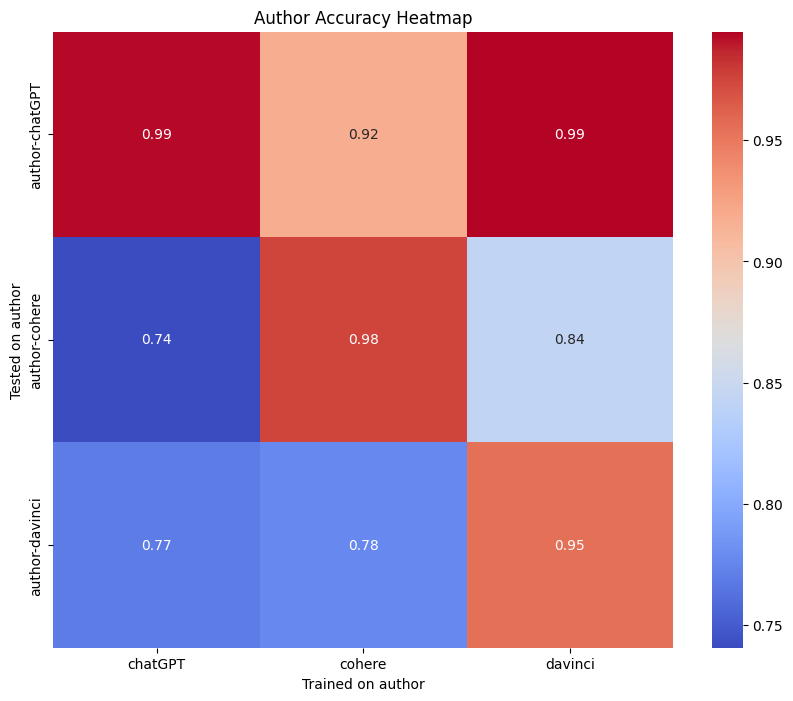

{'arxiv': {'domain-arxiv': 0.9281839318005684, 'domain-reddit': 0.9425465838509317, 'domain-wikipedia': 0.8912504427913567, 'domain-wikihow': 0.8561588693085249}, 'reddit': {'domain-reddit': 0.990293954520244, 'domain-wikipedia': 0.8948854469183608, 'domain-wikihow': 0.637321828409153, 'domain-arxiv': 0.8461738903847824}, 'wikihow': {'domain-wikihow': 0.9972451790633609, 'domain-reddit': 0.8124975092655322, 'domain-wikipedia': 0.8861384199600486, 'domain-arxiv': 0.888112927191679}, 'wikipedia': {'domain-wikipedia': 0.9907148120854827, 'domain-reddit': 0.8397762585456805, 'domain-wikihow': 0.6991288584520872, 'domain-arxiv': 0.8813201718031799}}


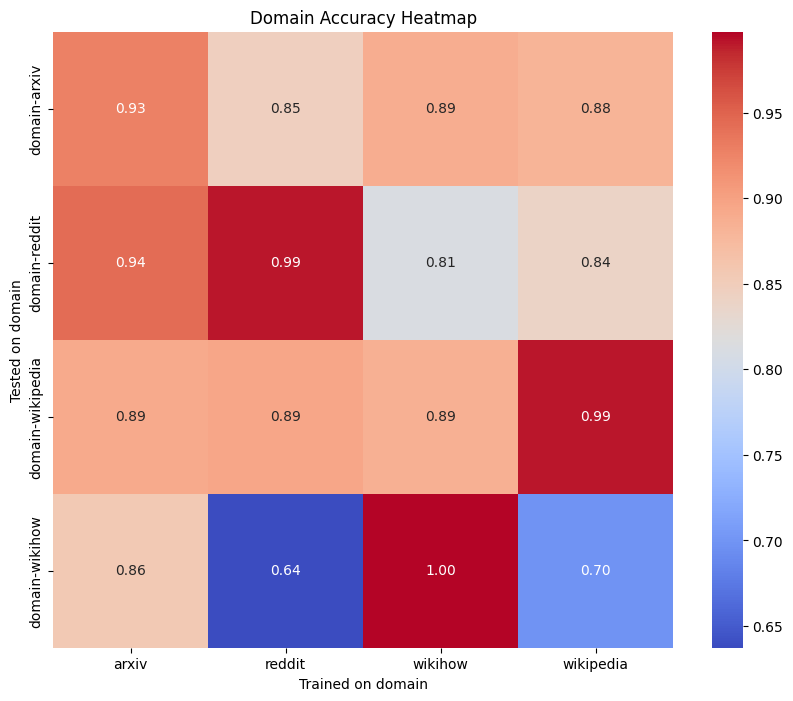

In [15]:
plot_data('author')
plot_data('domain')